In [1]:
import getdist
import matplotlib.pyplot as plt
from getdist import loadMCSamples

# Path to the directory and the base name of the chains
# If your files are: chains/my_run/2026-04-02_4000000__1.txt, etc.
file_root = '/home/jthybo/connect_public/resources/montepython_public/chains/SIDR_interacting_and_std_T_5_4mio/2026-04-02_4000000_'

# Load with 'chain_indices' or just the root; 
# GetDist will find all files matching that root.
samples = loadMCSamples(file_root, settings={'ignore_rows': 0.3})


In [2]:
import numpy as np
import arviz as az
from getdist import loadMCSamples, plots


# ---- 1. Extract raw chains ----
chains = samples.getSeparateChains()
param_names = samples.getParamNames().list()

# Truncate to shortest chain
min_len = min(chain.samples.shape[0] for chain in chains)
chain_array = np.array([chain.samples[:min_len, :] for chain in chains])  # (nchains, nsamples, nparams)

# ---- 2. Build a dict for ArviZ: split each param to (nchains, nsamples) ----
posterior_dict = {name: chain_array[:, :, i] for i, name in enumerate(param_names)}

# ---- 3. Convert to InferenceData correctly ----
# Need to wrap the dict in another dict with "posterior" key
idata = az.from_dict({"posterior": posterior_dict})

# ---- 4. Compute R-hat ----
rhat = az.rhat(idata)

# ---- 5. Print R-1 per parameter ----
print(f"{'Parameter':<30} | {'R-1':<12}")
print("-" * 45)

max_r_minus_1 = 0.0
for name in param_names:
    r_minus_1 = float(rhat[name].values - 1.0)
    max_r_minus_1 = max(max_r_minus_1, r_minus_1)
    print(f"{name:<30} | {r_minus_1:.6f}")

print("-" * 45)
print(f"Max Gelman-Rubin (R-1): {max_r_minus_1:.6f}")

g = plots.get_subplot_plotter()
g.triangle_plot(samples, filled=True)

# Optional: show plot if running in a notebook
import matplotlib.pyplot as plt
plt.show()

KeyboardInterrupt: 

In [ ]:
# Get separate chains from GetDist
chains = samples.getSeparateChains()

for i, chain in enumerate(chains):
    chain_mean = chain.samples.mean(axis=0)
    chain_std = chain.samples.std(axis=0)
    print(f"Chain {i}: mean={chain_mean[:5]}, std={chain_std[:5]}")

In [ ]:
import numpy as np

nchains = len(chains)
nparams = len(param_names)

# Truncate all chains to the same length
min_len = min(chain.samples.shape[0] for chain in chains)
chains_array = np.array([c.samples[:min_len, :] for c in chains])  # shape: (nchains, nsamples, nparams)

# Store per-chain R-1
per_chain_r1 = np.zeros((nchains, nparams))

def gelman_rubin(chain_matrix):
    """
    chain_matrix: shape (nchains, nsamples)
    Returns R-1
    """
    m, n = chain_matrix.shape
    mean_per_chain = np.mean(chain_matrix, axis=1)
    var_per_chain = np.var(chain_matrix, axis=1, ddof=1)
    
    W = np.mean(var_per_chain)
    B = n * np.var(mean_per_chain, ddof=1)
    
    var_hat = (n-1)/n * W + B/n
    R = np.sqrt(var_hat / W)
    return R - 1  # R-1

# Loop over chains
for i in range(nchains):
    # Take chain i vs all others combined
    other_chains = np.delete(chains_array, i, axis=0)
    combined = np.concatenate([chains_array[i:i+1], other_chains], axis=0)  # i-th chain + rest
    for j in range(nparams):
        per_chain_r1[i, j] = gelman_rubin(combined[:, :, j])

# Print nicely
for i in range(nchains):
    print(f"Chain {i} R-1 per param:")
    for j, name in enumerate(param_names):
        print(f"  {name:<25} {per_chain_r1[i,j]:.6f}")

Parameter                      | R-1         
---------------------------------------------
omega_b                        | 0.004557
omega_cdm                      | 0.010806
h                              | 0.012183
ln10^{10}A_s                   | 0.002286
n_s                            | 0.004308
tau_reio                       | 0.001419
r                              | 0.001288
m_ncdm_interacting             | 0.007557
log10G_eff_ncdm_interacting    | 0.003131
deg_ncdm_interacting           | 0.004499
m_ncdm_standard                | 0.004378
deg_ncdm_standard              | 0.006602
M                              | 0.395381
BBdust                         | 0.000111
BBsync                         | 0.000183
BBalphadust                    | 0.000071
BBbetadust                     | 0.000085
BBalphasync                    | 0.000141
BBbetasync                     | 0.000088
BBdustsynccorr                 | 0.000058
A_planck                       | 0.001190
H0                        

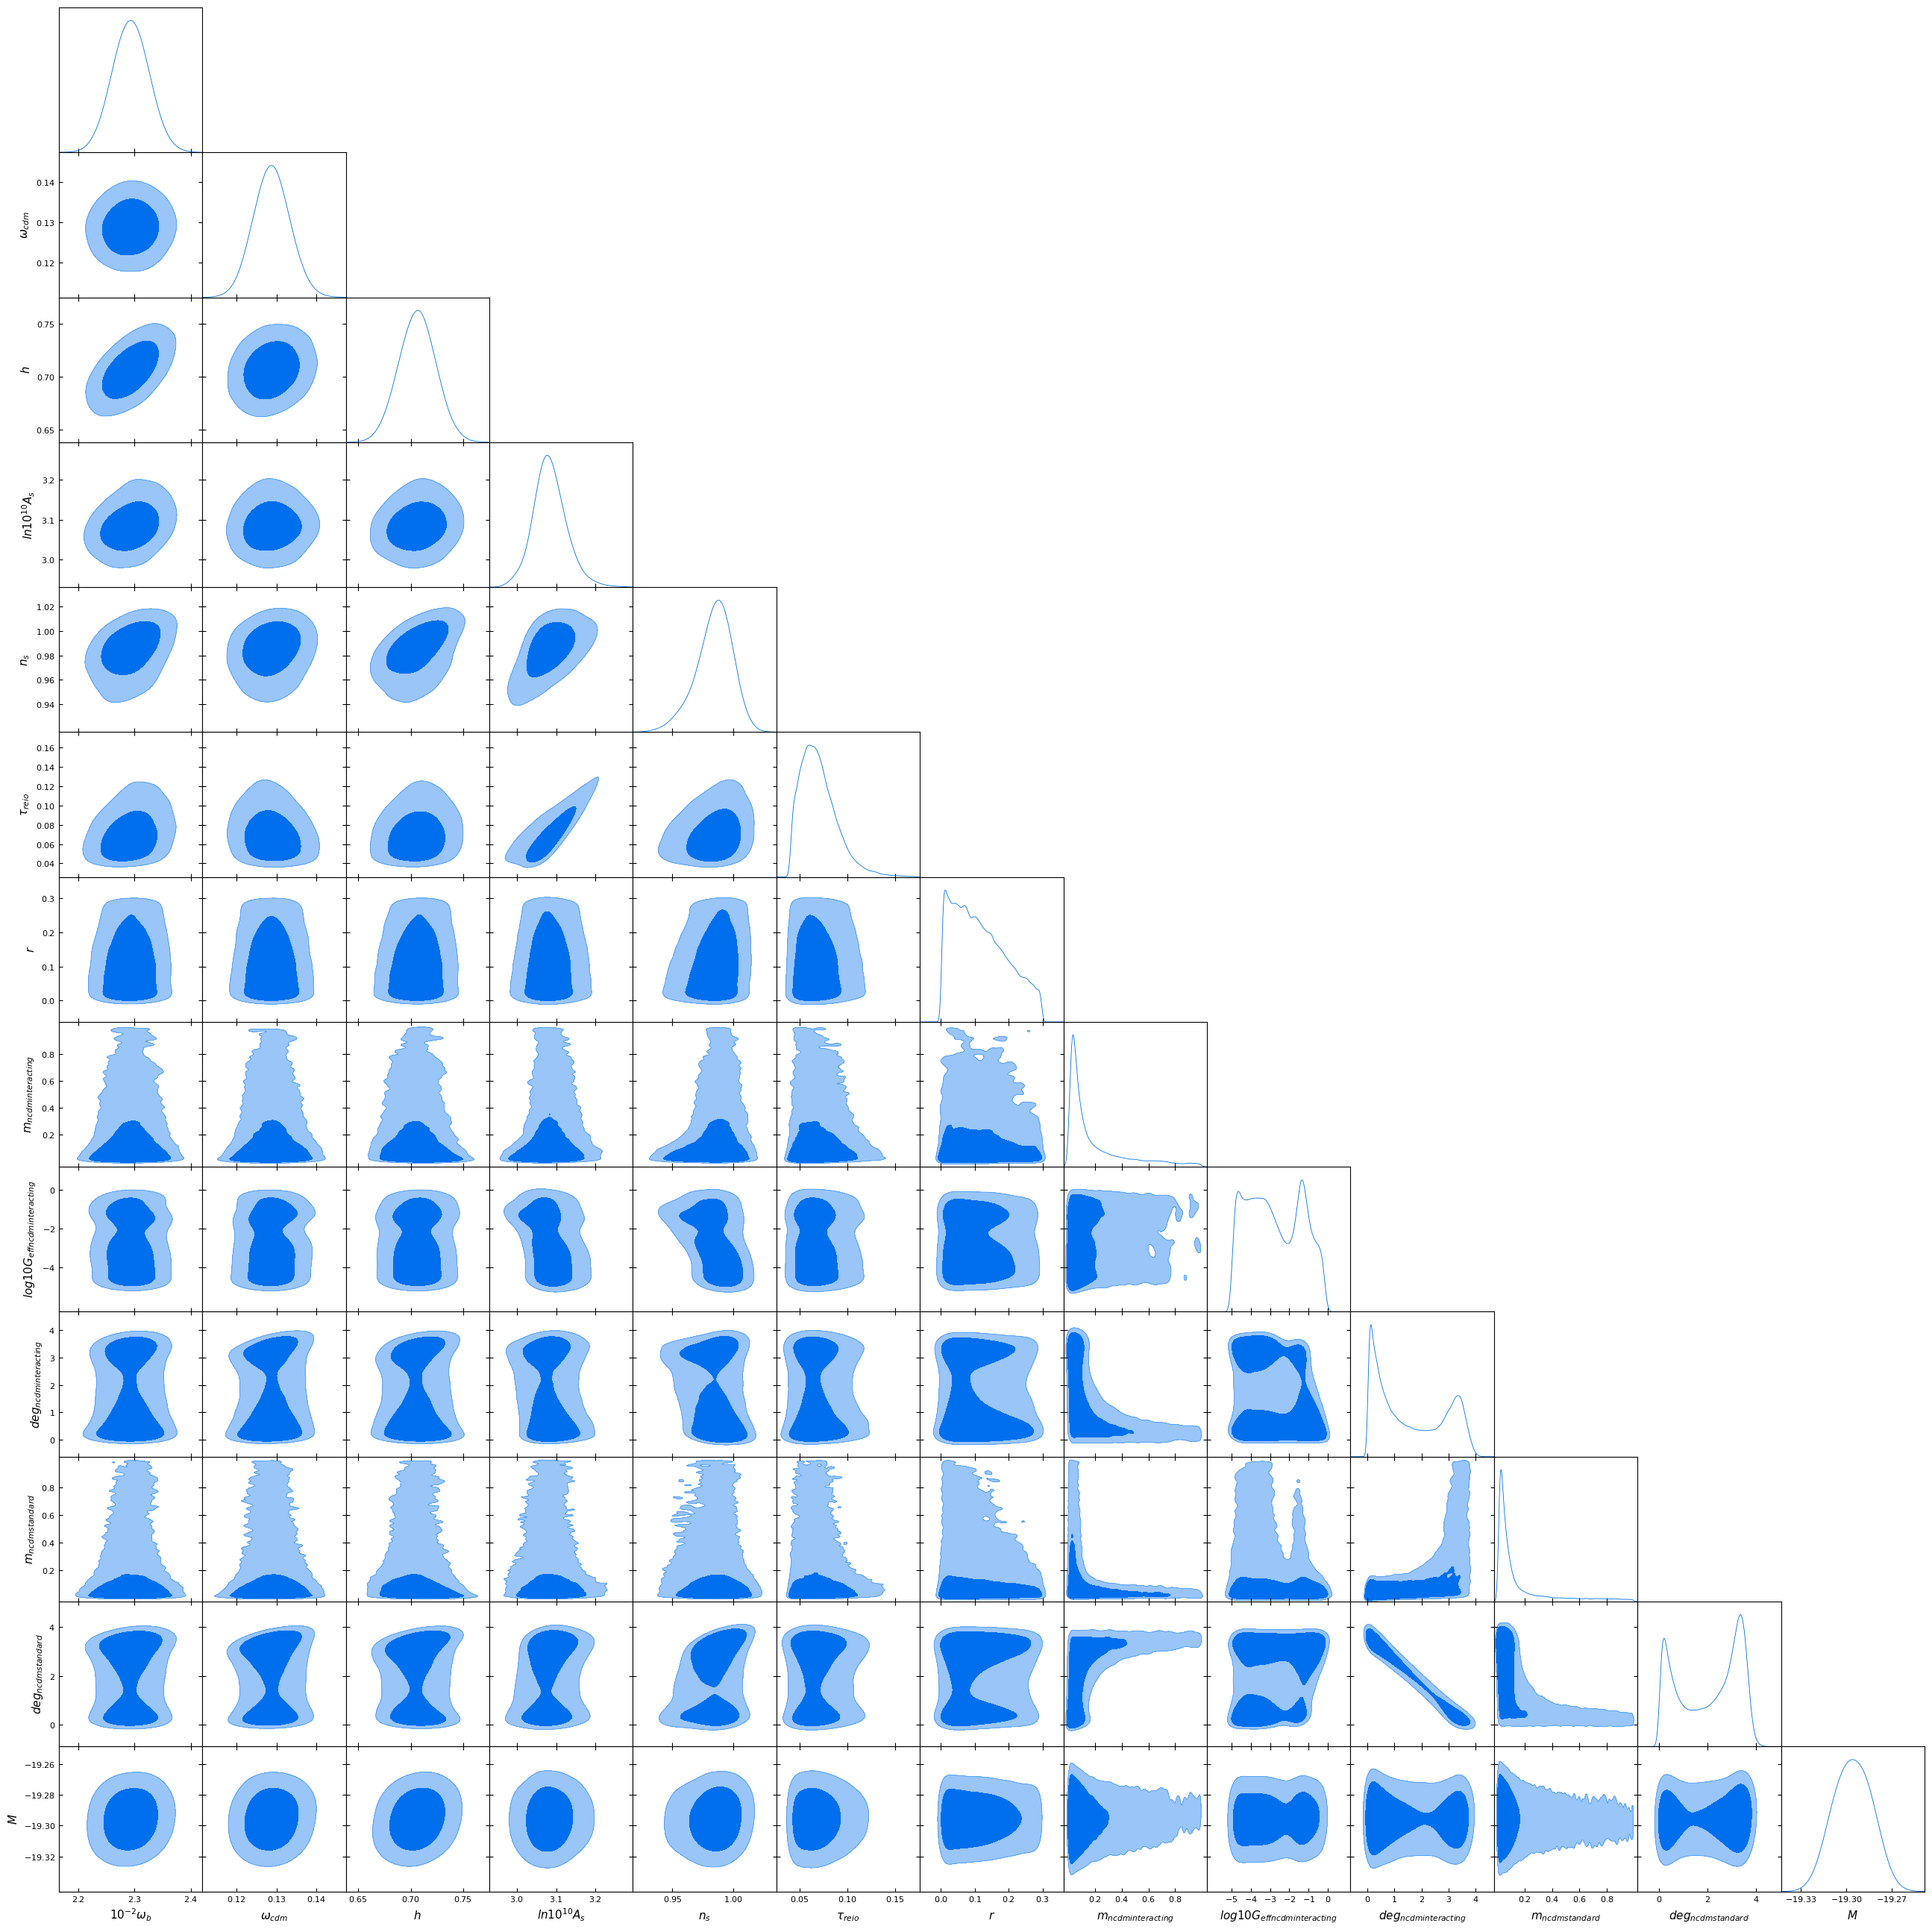

In [2]:
#SIDR_T5_M_tweaks
import getdist
import matplotlib.pyplot as plt
from getdist import loadMCSamples

# Path to the directory and the base name of the chains
# If your files are: chains/my_run/2026-04-02_4000000__1.txt, etc.
file_root = '/home/jthybo/connect_public/resources/montepython_public/chains/SIDR_interacting_and_std_T_5_2mio_M_tweaks/2026-04-09_2000000_'

# Load with 'chain_indices' or just the root; 
# GetDist will find all files matching that root.
samples = loadMCSamples(file_root, settings={'ignore_rows': 0.3})

import numpy as np
import arviz as az
from getdist import loadMCSamples, plots


# ---- 1. Extract raw chains ----
chains = samples.getSeparateChains()
param_names = samples.getParamNames().list()

# Truncate to shortest chain
min_len = min(chain.samples.shape[0] for chain in chains)
chain_array = np.array([chain.samples[:min_len, :] for chain in chains])  # (nchains, nsamples, nparams)

# ---- 2. Build a dict for ArviZ: split each param to (nchains, nsamples) ----
posterior_dict = {name: chain_array[:, :, i] for i, name in enumerate(param_names)}

# ---- 3. Convert to InferenceData correctly ----
# Need to wrap the dict in another dict with "posterior" key
idata = az.from_dict({"posterior": posterior_dict})

# ---- 4. Compute R-hat ----
rhat = az.rhat(idata)

# ---- 5. Print R-1 per parameter ----
print(f"{'Parameter':<30} | {'R-1':<12}")
print("-" * 45)

max_r_minus_1 = 0.0
for name in param_names:
    r_minus_1 = float(rhat[name].values - 1.0)
    max_r_minus_1 = max(max_r_minus_1, r_minus_1)
    print(f"{name:<30} | {r_minus_1:.6f}")

print("-" * 45)
print(f"Max Gelman-Rubin (R-1): {max_r_minus_1:.6f}")

g = plots.get_subplot_plotter()
params_to_plot = [
    "omega_b",
    "omega_cdm",
    "h",
    "ln10^{10}A_s",
    "n_s",
    "tau_reio",
    "r",
    "m_ncdm_interacting",
    "log10G_eff_ncdm_interacting",
    "deg_ncdm_interacting",
    "m_ncdm_standard",
    "deg_ncdm_standard",
    "M"
]

g.triangle_plot(samples, params=params_to_plot, filled=True)
# Optional: show plot if running in a notebook
import matplotlib.pyplot as plt
plt.show()
